# Supervised Learning Methods

In [1]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#dataset
from sklearn.datasets import load_breast_cancer

#for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Task 1: Data Loading & Exploration (Víctor)

In [2]:
#display options
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')

#load the dataset
data = load_breast_cancer()

#build the df and separate the target
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

#transform the target into 0-1 instead of malignant-benign
class_names = dict(enumerate(data.target_names))
print('Class label mapping:', class_names)

Class label mapping: {0: np.str_('malignant'), 1: np.str_('benign')}


In [3]:
#shape and NA
print(f'Feature matrix X shape: {X.shape}')
print(f'Target vector y shape:  {y.shape}')
print('Data types of features:')
print(X.dtypes.value_counts())
print("\n")
print('Missing values in X?', X.isna().any().any())
print('Missing values in y?', y.isna().any())
print("\n")
X.head()

Feature matrix X shape: (569, 30)
Target vector y shape:  (569,)
Data types of features:
float64    30
Name: count, dtype: int64


Missing values in X? False
Missing values in y? False




,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


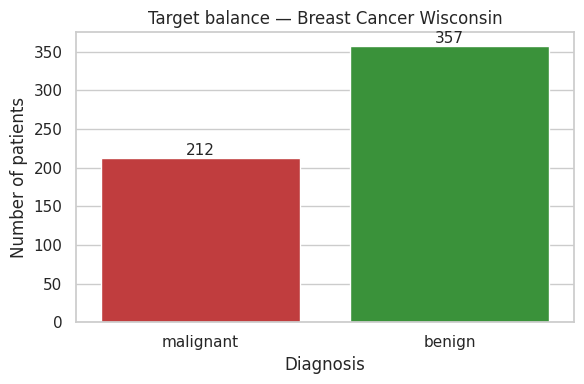

In [4]:
#target balance
counts = y.value_counts().sort_index()
proportions = y.value_counts(normalize=True).sort_index()

balance = pd.DataFrame({
    'count': counts,
    'proportion': proportions.round(3)
})
balance.index = [class_names[i] for i in balance.index]
balance

# Bar plot of target counts
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=y.map(class_names), order=['malignant', 'benign'],
              hue=y.map(class_names),
              palette={'malignant': '#d62728', 'benign': '#2ca02c'},
              legend=False, ax=ax)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
ax.set_title('Target balance — Breast Cancer Wisconsin')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Number of patients')
plt.tight_layout()
plt.show()

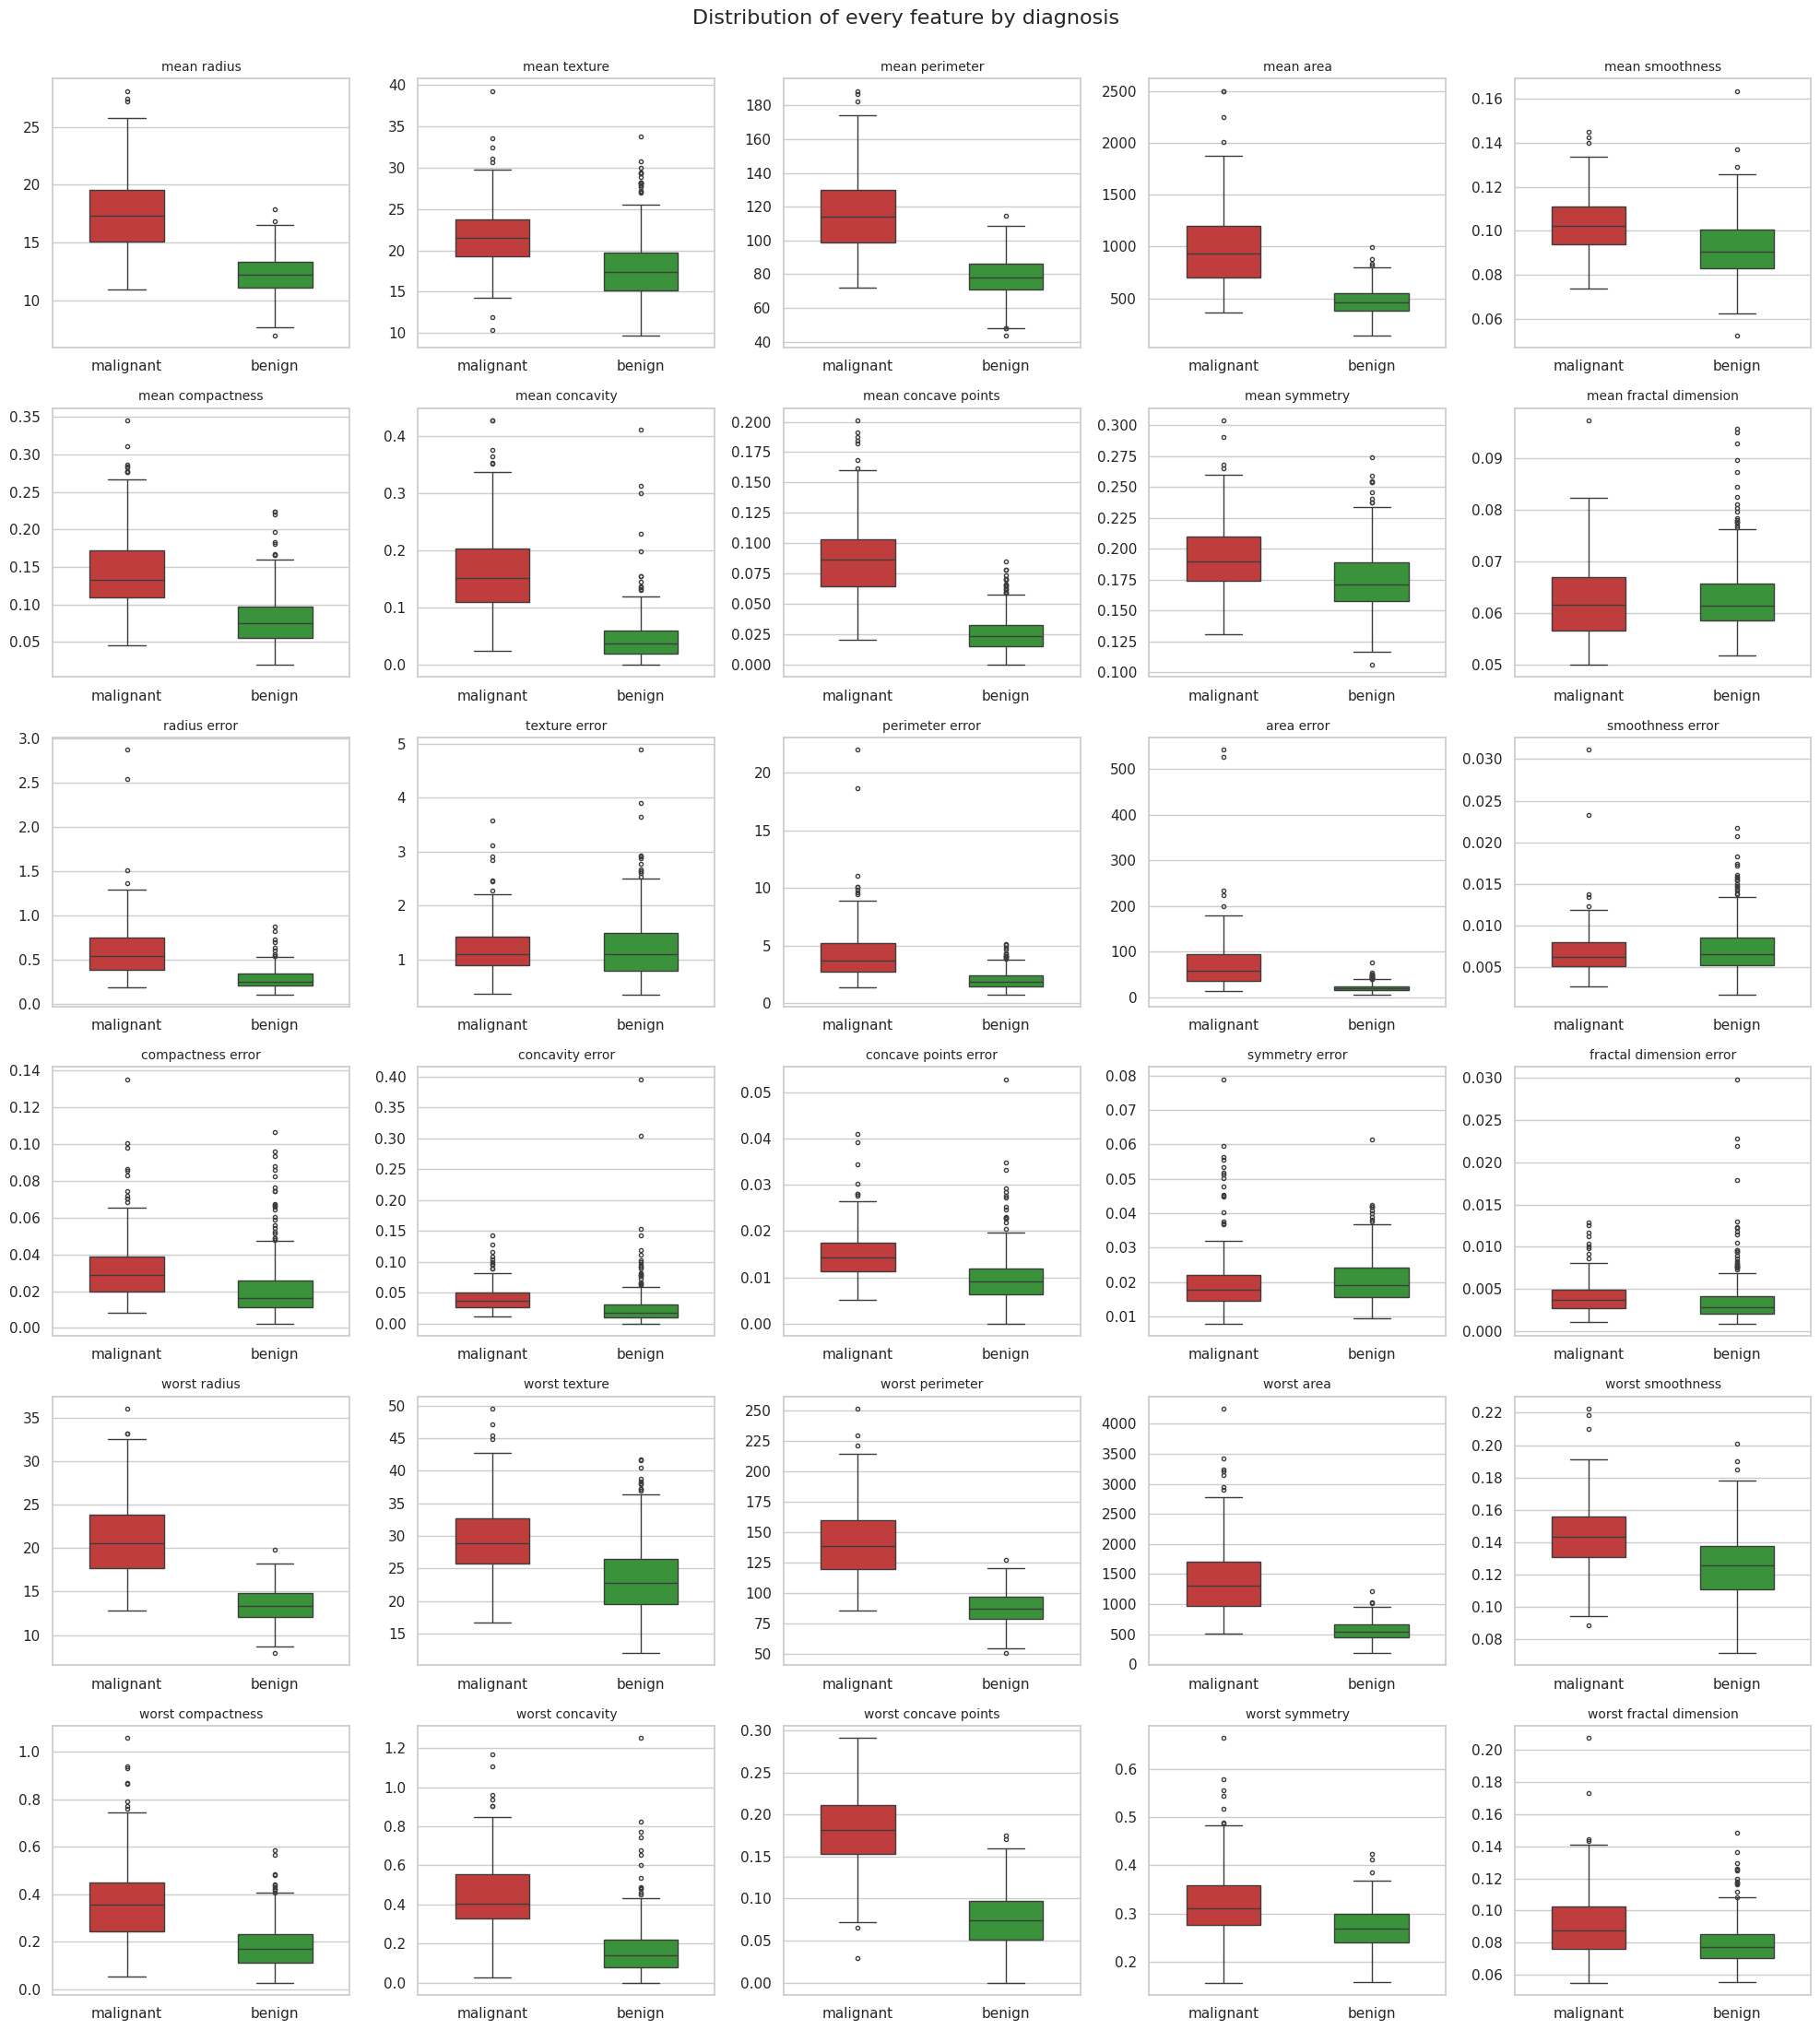

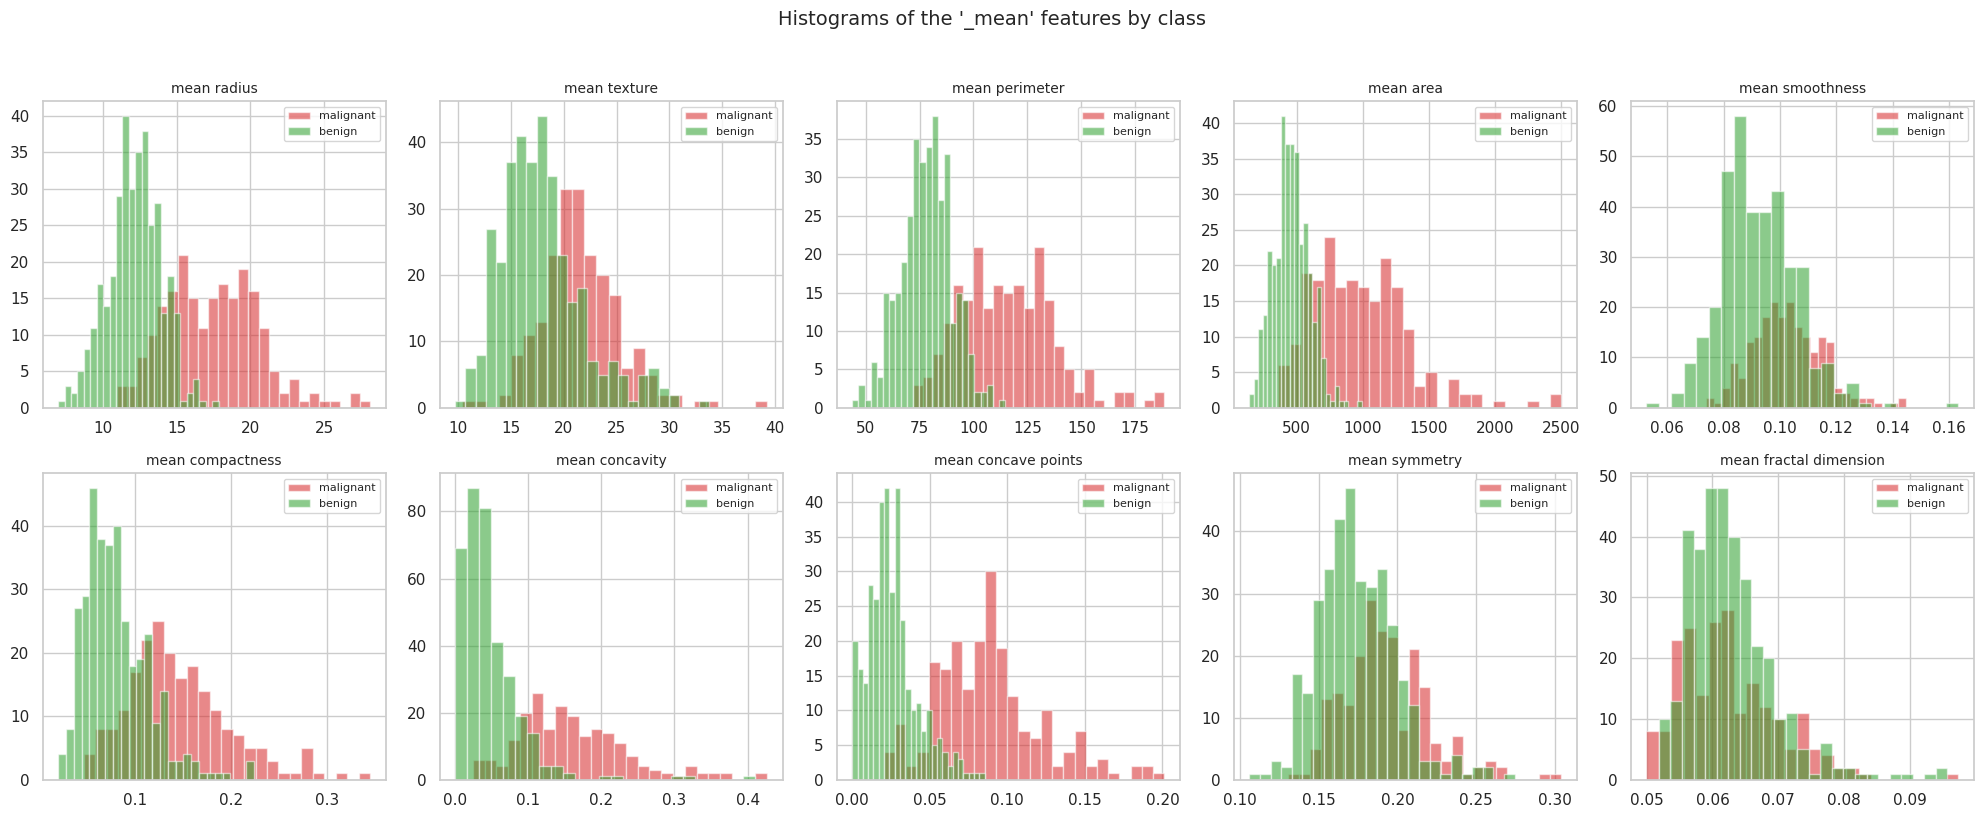

In [5]:
#summary statistics
X.describe().T

#we add a colum with the target for looking what feature separates better the target classes
df_long = X.copy()
df_long['diagnosis'] = y.map(class_names)

feature_groups = ['mean', 'error', 'worst']
fig, axes = plt.subplots(6, 5, figsize=(20, 22))
axes = axes.flatten()

palette = {'malignant': '#d62728', 'benign': '#2ca02c'}

for i, feat in enumerate(X.columns):
    sns.boxplot(data=df_long, x='diagnosis', y=feat,
            order=['malignant', 'benign'],
            hue='diagnosis', palette=palette, legend=False,
            ax=axes[i], width=0.5, fliersize=3)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.suptitle('Distribution of every feature by diagnosis', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

#histograms for the 'mean' feature group
mean_features = [c for c in X.columns if c.startswith('mean')]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, feat in enumerate(mean_features):
    for cls_id, cls_name in class_names.items():
        axes[i].hist(X.loc[y == cls_id, feat], bins=25, alpha=0.55,
                     label=cls_name, color=palette[cls_name])
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=8)
plt.suptitle("Histograms of the '_mean' features by class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

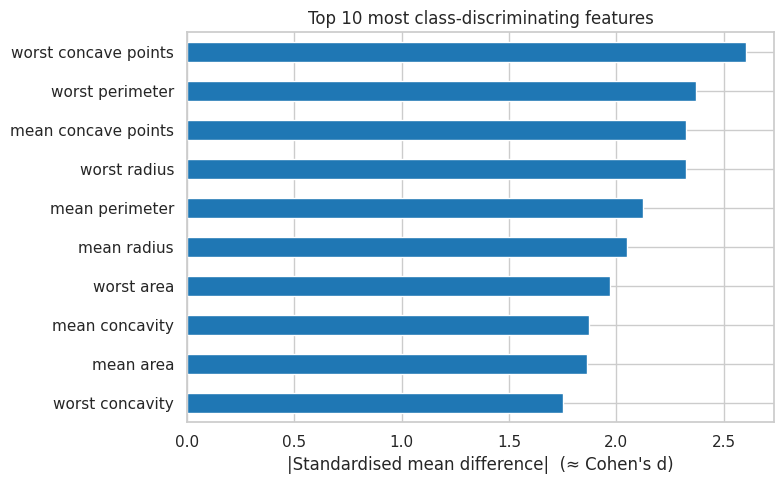

Top 10 features by separating power:
worst concave points    2.60
worst perimeter         2.37
mean concave points     2.33
worst radius            2.32
mean perimeter          2.12
mean radius             2.05
worst area              1.97
mean concavity          1.87
mean area               1.86
worst concavity         1.75


In [6]:
#we look (objectibly) what variables distinguish better both classes (malignant-benign)
def standardised_mean_diff(x, group): #cohen's d
    g0 = x[group == 0]
    g1 = x[group == 1]
    pooled_std = np.sqrt((g0.var(ddof=1) + g1.var(ddof=1)) / 2)
    if pooled_std == 0:
        return 0.0
    return (g0.mean() - g1.mean()) / pooled_std

smd = X.apply(lambda col: standardised_mean_diff(col, y)) #apply for every colum
smd_sorted = smd.abs().sort_values(ascending=False)

top10 = smd_sorted.head(10)
fig, ax = plt.subplots(figsize=(8, 5))
top10.iloc[::-1].plot(kind='barh', color='#1f77b4', ax=ax)
ax.set_xlabel("|Standardised mean difference|  (≈ Cohen's d)")
ax.set_title('Top 10 most class-discriminating features')
plt.tight_layout()
plt.show()

print('Top 10 features by separating power:')
print(top10.round(2).to_string())

We can see that all these variables have a Cohen's d > 1.5, which means that the variable itself is good separating the classes.

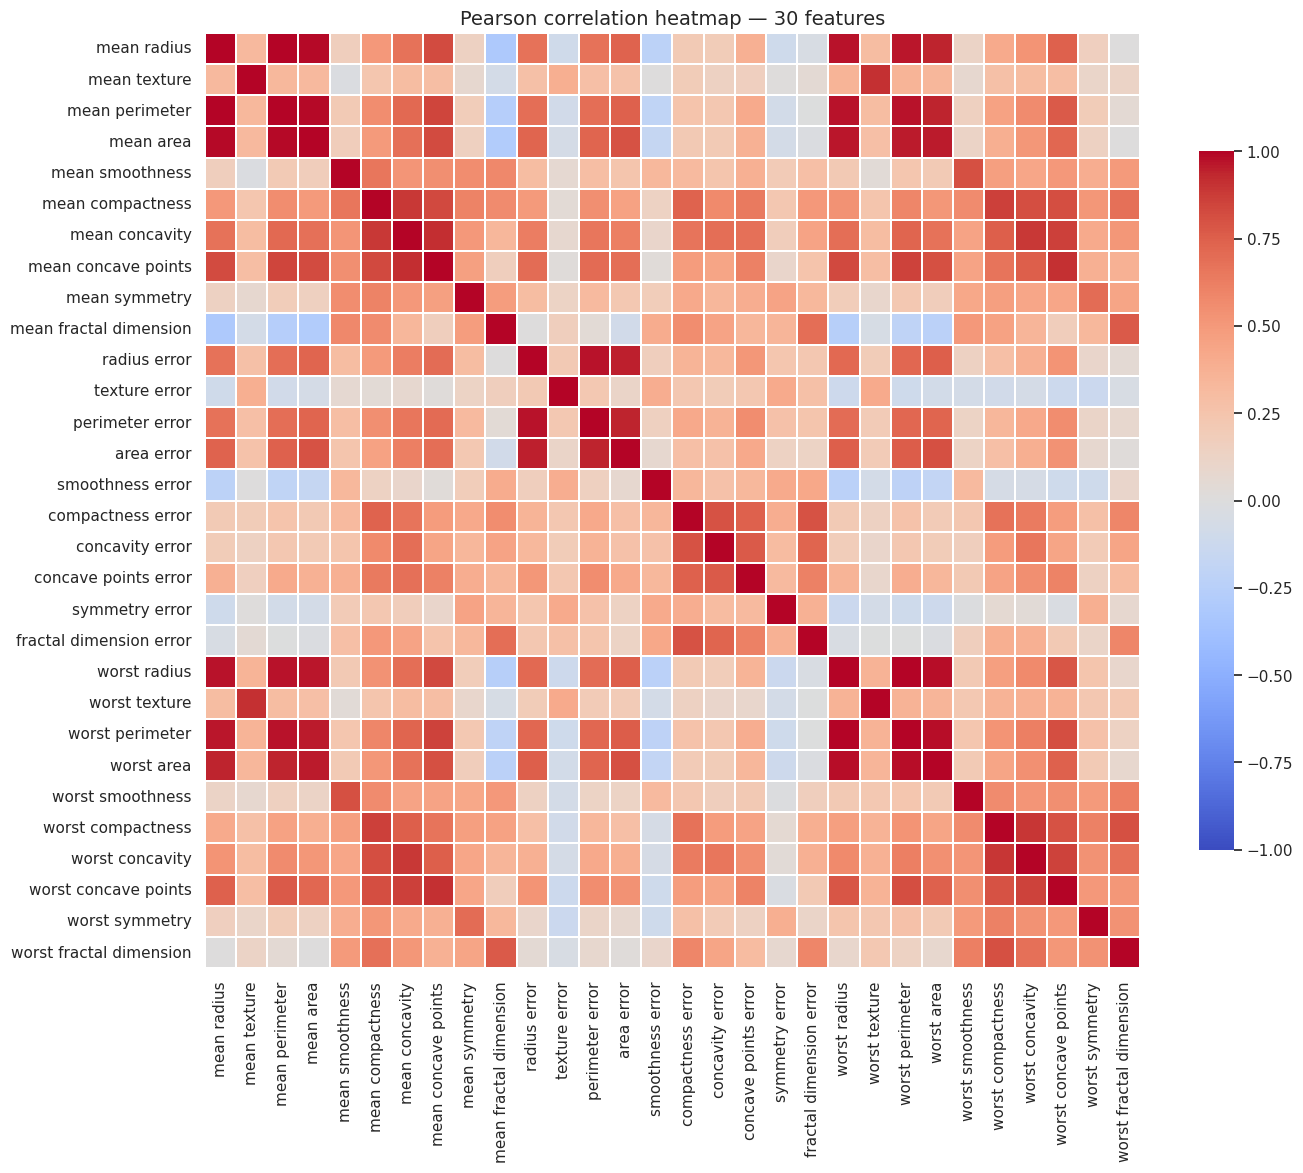

,feature_1,feature_2,corr,abs_corr
0,mean radius,mean perimeter,0.998,0.998
1,worst radius,worst perimeter,0.994,0.994
2,mean radius,mean area,0.987,0.987
3,mean perimeter,mean area,0.987,0.987
4,worst radius,worst area,0.984,0.984
5,worst perimeter,worst area,0.978,0.978
6,radius error,perimeter error,0.973,0.973
7,mean perimeter,worst perimeter,0.970,0.970
8,mean radius,worst radius,0.970,0.970
9,mean perimeter,worst radius,0.969,0.969


In [7]:
#correlations

corr = X.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Pearson correlation heatmap — 30 features', fontsize=14)
plt.tight_layout()
plt.show()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
pairs = (
    corr.where(mask)
        .stack()
        .rename('corr')
        .reset_index()
        .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
)
#rank pair with most correlation
pairs['abs_corr'] = pairs['corr'].abs()
top_pairs = pairs.sort_values('abs_corr', ascending=False).head(15).reset_index(drop=True)
top_pairs.round(3)

### Discussion of top correlated pairs

The 15 most correlated feature pairs all show |r| > 0.95, exposing strong multicollinearity in the dataset. We can see two main patterns:

1. **Size-related features.** The strongest correlations involve radius, perimeter and area.

   This is geometrically expected as for an approximately circular nucleus, perimeter is approximately 2·π·radius and area is approximately π·radius², so the three features are essentially redundant measurements of size.

2. **Cross-statistic redundancy.** The mean and worst versions of the same feature are also highly correlated. This indicates that tumours with a large mean nucleus size also tend to contain the largest individual nuclei.

## Task 2: Preprocessing & Feature Analysis (Irene)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# split the data into training (80%) and test (20%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

# training based normalisation for the models sensitive to feature scale
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to df
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("Training samples: ", X_train.shape[0])
print("Test samples:     ", X_test.shape[0])

# check target is splitted evenly in train and test dataset
print("Target proportion in train dataset:\n", pd.Series(y_train).value_counts(normalize=True))
print("Target proportion in test dataset:\n", pd.Series(y_test).value_counts(normalize=True))

Training samples:  455
Test samples:      114
Target proportion in train dataset:
 target
1    0.626374
0    0.373626
Name: proportion, dtype: float64
Target proportion in test dataset:
 target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


## Task 3: K-Nearest Neighbours (Kamela)

This section evaluates K-Nearest Neighbours classifiers for \(k = 1\) to \(k = 20\). For each value of \(k\), the model is trained on the scaled training data and evaluated on the scaled test data using accuracy.

KNN is distance-based, so feature scaling is essential. The scaled datasets created in Task 2 are used here to ensure that features with larger numerical ranges do not dominate the distance calculation.

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
import time

### 3.1 Hyperparameter sweep for \(k\)

The number of neighbours, \(k\), controls the flexibility of the KNN model. The following loop trains one KNN classifier for each value of \(k\) from 1 to 20 and records the corresponding test accuracy.

In [10]:
# Define the range of k values required by the assignment
k_values = range(1, 21)

# Store test accuracy for each k
knn_accuracies = []

# Train and evaluate one KNN model for each k value
for k in k_values:
    # Create KNN classifier with the current number of neighbours
    knn = KNeighborsClassifier(n_neighbors=k)

    # Fit the model using the scaled training data
    knn.fit(X_train_scaled, y_train)

    # Predict labels for the scaled test data
    y_pred = knn.predict(X_test_scaled)

    # Calculate test accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Save the accuracy for later comparison
    knn_accuracies.append(accuracy)

# Store the results in a DataFrame for clear display
knn_results = pd.DataFrame({
    "k": list(k_values),
    "test_accuracy": knn_accuracies
})

knn_results

,k,test_accuracy
0,1,0.938596
1,2,0.929825
2,3,0.982456
3,4,0.947368
4,5,0.956140
5,6,0.956140
6,7,0.973684
7,8,0.973684
8,9,0.973684
9,10,0.964912


### 3.2 Accuracy curve

The accuracy values are plotted against \(k\) to visually compare model performance and identify the best-performing number of neighbours.

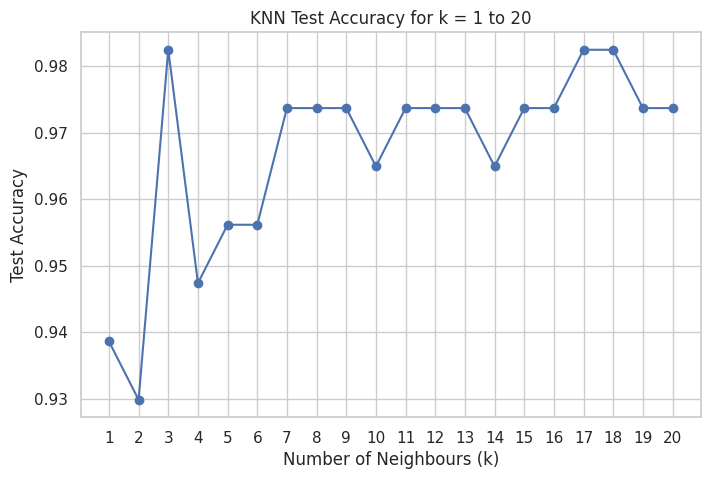

In [11]:
# Create the accuracy vs k plot
plt.figure(figsize=(8, 5))

plt.plot(
    knn_results["k"],
    knn_results["test_accuracy"],
    marker="o"
)

# Show every k value from 1 to 20 on the x-axis
plt.xticks(range(1, 21))

# Add clear axis labels and title
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Test Accuracy")
plt.title("KNN Test Accuracy for k = 1 to 20")

# Add grid for readability
plt.grid(True)

plt.show()

### 3.3 Selecting the optimal \(k\)

The optimal value of \(k\) is selected as the value with the highest test accuracy. If multiple values achieve the same maximum accuracy, the first occurrence is selected by `idxmax()`.

In [12]:
# Find the row index with the highest test accuracy
best_index = knn_results["test_accuracy"].idxmax()

# Extract the corresponding k value and accuracy
best_k = int(knn_results.loc[best_index, "k"])
best_knn_accuracy = knn_results.loc[best_index, "test_accuracy"]

print(f"Best k: {best_k}")
print(f"Best test accuracy: {best_knn_accuracy:.4f}")

Best k: 3
Best test accuracy: 0.9825


The best value of \(k\) was selected based on the highest test accuracy across the tested range from 1 to 20. In this run, the selected value was \(k = 3\), with a test accuracy of approximately 98.25%.

Smaller values of \(k\), especially \(k = 1\), create a more flexible model that can capture very local patterns in the training data. However, this may increase variance and lead to overfitting because predictions depend strongly on individual nearby points.

Larger values of \(k\) produce a smoother decision boundary by averaging over more neighbours. This can reduce variance, but if \(k\) becomes too large, the model may underfit by ignoring useful local structure.

Therefore, \(k = 3\) was selected as the final KNN setting because it achieved the highest observed test accuracy while still keeping the model relatively simple.

### 3.4 Final KNN model

The final KNN classifier is trained using the selected value of \(k\). The training time is recorded so that KNN can later be compared with the other supervised learning models in Task 7.

In [13]:
# Start timer to measure training time
start_time = time.time()

# Train final KNN model using the selected k
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

# Stop timer after model fitting
knn_train_time = time.time() - start_time

# Predict class labels on the scaled test set
y_pred_knn = final_knn.predict(X_test_scaled)

# Predict class probabilities for ROC/AUC calculation
# Column 1 corresponds to the positive class: benign
y_proba_knn = final_knn.predict_proba(X_test_scaled)[:, 1]

### 3.5 Classification report

The classification report shows precision, recall, and F1-score for both malignant and benign cases, as well as overall accuracy.

In [14]:
# Print precision, recall, F1-score, and support for each class
print("Classification Report for Final KNN Model")
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=["malignant", "benign"]
    )
)

Classification Report for Final KNN Model
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### 3.6 Confusion matrix

The confusion matrix shows the number of correct and incorrect predictions for each class. This is especially useful in a medical setting because false negatives for malignant cases are clinically important.

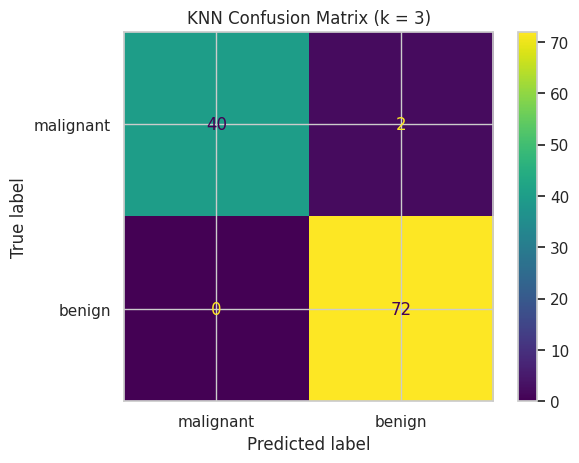

In [15]:
# Compute confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Display confusion matrix with class labels
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["malignant", "benign"]
)

disp.plot()
plt.title(f"KNN Confusion Matrix (k = {best_k})")
plt.show()

### 3.7 Saving KNN results for model comparison

The key KNN evaluation metrics are saved in the shared `results` dictionary. These values will be reused later for the global model comparison, summary table, and ROC curve in Task 7.

In [16]:
# Calculate final evaluation metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_f1_macro = f1_score(y_test, y_pred_knn, average="macro")

# Calculate ROC curve and AUC
knn_fpr, knn_tpr, _ = roc_curve(y_test, y_proba_knn)
knn_auc = auc(knn_fpr, knn_tpr)

# Create results dictionary if it does not already exist
if "results" not in globals():
    results = {}

# Store KNN metrics for later comparison with other models
results["KNN"] = {
    "accuracy": knn_accuracy,
    "f1_macro": knn_f1_macro,
    "auc": knn_auc,
    "train_time": knn_train_time,
    "fpr": knn_fpr,
    "tpr": knn_tpr
}

results["KNN"]

{'accuracy': 0.9824561403508771,
 'f1_macro': 0.9809555629802873,
 'auc': np.float64(0.9834656084656085),
 'train_time': 0.005473136901855469,
 'fpr': array([0.        , 0.02380952, 0.04761905, 0.0952381 , 1.        ]),
 'tpr': array([0.        , 0.80555556, 1.        , 1.        , 1.        ])}

The final KNN model achieved strong performance, with high accuracy, macro F1-score, and ROC AUC. The confusion matrix shows that most test observations were correctly classified.

In a clinical classification problem, false negatives are particularly important because they represent malignant tumours incorrectly predicted as benign. In this result, the malignant recall should therefore be interpreted carefully alongside the overall accuracy.

The KNN results have also been saved in the shared `results` dictionary so they can be included in the final model comparison in Task 7.

## Task 4: Logistic Regression (Ana)

This section evaluates a Logistic Regression classifier using different values of the regularization hyperparameter ( C ). For each value of ( C ), the model is trained on the scaled training data and evaluated on the scaled test data using metrics such as accuracy and ROC-AUC.

Logistic Regression is sensitive to feature magnitudes due to the regularization term, making feature scaling important. Therefore, the scaled datasets created in Task 2 are used to ensure that all features contribute equally to the model training process.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report, confusion_matrix, f1_score
import time
from sklearn.metrics import ConfusionMatrixDisplay

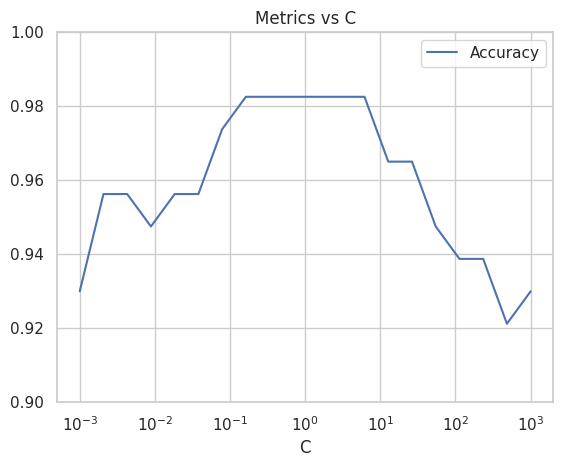

Best C by Accuracy: 0.1624 with Accuracy: 0.9825


In [18]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

C_values = np.logspace(-3, 3, 20)

accs = []

for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000)
    lr.fit(X_train_scaled_df, y_train)

    y_pred = lr.predict(X_test_scaled_df)
    y_prob = lr.predict_proba(X_test_scaled_df)[:, 1]

    accs.append(lr.score(X_test_scaled_df, y_test))

plt.figure()
plt.plot(C_values, accs, label='Accuracy')
plt.xscale('log')
plt.ylim(0.9, 1)
plt.legend()
plt.xlabel('C')
plt.title('Metrics vs C')
plt.show()

best_C_acc = C_values[np.argmax(accs)]
print(f'Best C by Accuracy: {best_C_acc:.4f} with Accuracy: {max(accs):.4f}')

The hyperparameter (C) controls the inverse strength of regularization in Logistic Regression. Since the selected C is a small value, this indicates stronger regularization, leading to a simpler model with smaller coefficients. In contrast, larger values reduce regularization and allow the model to fit the training data more closely.

### 4.1 Final Logistic Regression Model

After selecting the optimal regularization parameter ( C ) based on the accuracy, the final Logistic Regression model is trained using the scaled training data. The model is then evaluated on the test set through classification metrics and confusion matrices.

In [19]:
# Training the Final Model
best_lr = LogisticRegression(C=best_C_acc, max_iter=1000)

time_start = time.time()
best_lr.fit(X_train_scaled_df, y_train)
time_end = time.time()
train_time = time_end - time_start  # training time
print(f'Training time for Logistic Regression with C={best_C_acc:.4f}: {train_time:.4f} seconds')

y_pred = best_lr.predict(X_test_scaled_df)
y_prob = best_lr.predict_proba(X_test_scaled_df)[:, 1]

# Classification Report
print(f'Classification report for Logistic Regression with C={best_C_acc:.4f}:')
print("---" * 20)
print(classification_report(y_test, y_pred))

# Confusion Matrix
print(f'Confusion matrix for Logistic Regression with C={best_C_acc:.4f}:')
print("---" * 20)
cm = confusion_matrix(y_test, y_pred)
print(cm)

Training time for Logistic Regression with C=0.1624: 0.0507 seconds
Classification report for Logistic Regression with C=0.1624:
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion matrix for Logistic Regression with C=0.1624:
------------------------------------------------------------
[[41  1]
 [ 1 71]]


The Logistic Regression model with (C = 0.1624) achieved a very fast training time (approximately 0.01 seconds), making it highly efficient in terms of computational cost.

In terms of performance, the model shows excellent results, with an overall accuracy of 0.98. Both classes are well predicted, with very balanced precision, recall, and F1-scores (all around 0.98–0.99). This indicates that the model performs consistently across both benign and malignant cases.

The confusion matrix confirms these results, with only two misclassifications in total: one false positive and one false negative. This suggests that the model has a very low error rate and maintains a good balance between sensitivity and specificity, which is particularly important in this context where both types of errors can have significant consequences.


### 4.2 Threshold Analysis

Different classification thresholds are evaluated to analyze the trade-off between false positives and false negatives and determine whether a threshold other than the default value of 0.5 improves the model performance.


In [20]:
# we compute the confusion matrices for different thresholds
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)

    cm = confusion_matrix(y_test, y_pred_thresh)

    tn, fp, fn, tp = cm.ravel()

    print(f"Threshold: {t:.2f}")
    print(cm)
    print(f"FP: {fp}, FN: {fn}")
    print("-" * 30)

Threshold: 0.00
[[ 0 42]
 [ 0 72]]
FP: 42, FN: 0
------------------------------
Threshold: 0.01
[[29 13]
 [ 0 72]]
FP: 13, FN: 0
------------------------------
Threshold: 0.02
[[31 11]
 [ 0 72]]
FP: 11, FN: 0
------------------------------
Threshold: 0.03
[[33  9]
 [ 0 72]]
FP: 9, FN: 0
------------------------------
Threshold: 0.04
[[34  8]
 [ 0 72]]
FP: 8, FN: 0
------------------------------
Threshold: 0.05
[[35  7]
 [ 0 72]]
FP: 7, FN: 0
------------------------------
Threshold: 0.06
[[36  6]
 [ 0 72]]
FP: 6, FN: 0
------------------------------
Threshold: 0.07
[[36  6]
 [ 0 72]]
FP: 6, FN: 0
------------------------------
Threshold: 0.08
[[36  6]
 [ 0 72]]
FP: 6, FN: 0
------------------------------
Threshold: 0.09
[[36  6]
 [ 0 72]]
FP: 6, FN: 0
------------------------------
Threshold: 0.10
[[36  6]
 [ 0 72]]
FP: 6, FN: 0
------------------------------
Threshold: 0.11
[[36  6]
 [ 0 72]]
FP: 6, FN: 0
------------------------------
Threshold: 0.12
[[36  6]
 [ 0 72]]
FP: 6, FN: 0
-

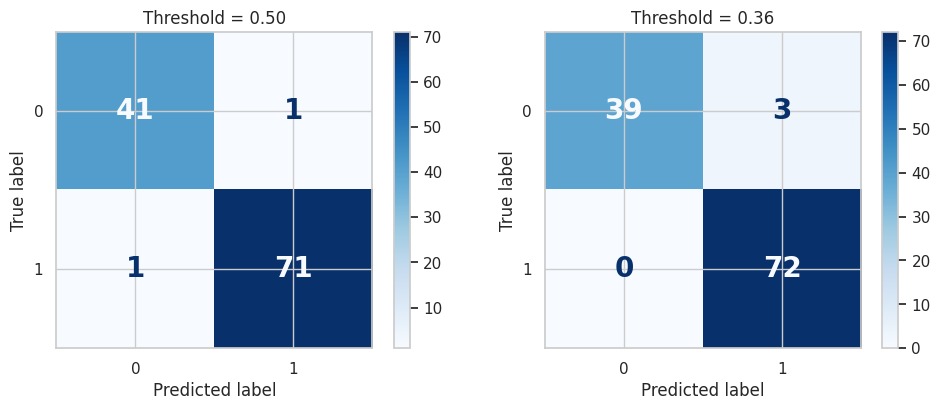

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Threshold 0.5
y_pred_05 = (y_prob >= 0.5).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_05, ax=ax[0], cmap='Blues'
)
ax[0].set_title("Threshold = 0.50")

for text in ax[0].texts:
    text.set_fontsize(20)
    text.set_fontweight('bold')

# Threshold 0.36
y_pred_036 = (y_prob >= 0.36).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_036, ax=ax[1], cmap='Blues'
)
ax[1].set_title("Threshold = 0.36")

for text in ax[1].texts:
    text.set_fontsize(20)
    text.set_fontweight('bold')

plt.tight_layout()
plt.show()

There is no threshold better than 0.5 that provides a better balance between false positives and false negatives. However, if we prioritize minimizing false negatives due to their higher clinical consequences, we could consider thresholds between 0.36 and 0.34, as these values achieve zero false negatives while keeping the number of false positives relatively low (3).

### 4.3 Storing Model Performance Metrics (for task 7)

The key logistic regression evaluation metrics are saved in the shared `results` dictionary. These values will be reused later for the global model comparison, summary table, and ROC curve in Task 7.

In [22]:
acc = best_lr.score(X_test_scaled_df, y_test)
f1 = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)  # for global ROC curve

results['Logistic Regression'] = {
    'accuracy': acc,
    'f1_macro': f1,
    'auc': auc,
    'train_time': train_time,
    'fpr': fpr,  # to plot the global ROC curve
    'tpr': tpr
}

### 4.4 Logistic Regression Coefficients

The coefficients of the Logistic Regression model are analyzed to identify the most influential features in the classification task. Features are ranked according to the absolute magnitude of their coefficients.

In [23]:
# Extract the coefficients
coefficients = best_lr.coef_[0]

coef_df = pd.DataFrame({
    'feature': X_train_scaled_df.columns,
    'coefficient': coefficients
})

coef_df['abs_coef'] = coef_df['coefficient'].abs() # for sorting by absolute value
coef_df_sorted = coef_df.sort_values(by='abs_coef', ascending=False)

print(coef_df_sorted)

                    feature  coefficient  abs_coef
21            worst texture    -0.665360  0.665360
27     worst concave points    -0.585858  0.585858
20             worst radius    -0.583769  0.583769
10             radius error    -0.538890  0.538890
23               worst area    -0.534519  0.534519
22          worst perimeter    -0.524968  0.524968
28           worst symmetry    -0.499144  0.499144
1              mean texture    -0.492224  0.492224
7       mean concave points    -0.455610  0.455610
13               area error    -0.450377  0.450377
24         worst smoothness    -0.440674  0.440674
0               mean radius    -0.432941  0.432941
26          worst concavity    -0.426605  0.426605
3                 mean area    -0.416424  0.416424
2            mean perimeter    -0.415615  0.415615
12          perimeter error    -0.363555  0.363555
6            mean concavity    -0.344381  0.344381
15        compactness error     0.308135  0.308135
19  fractal dimension error    

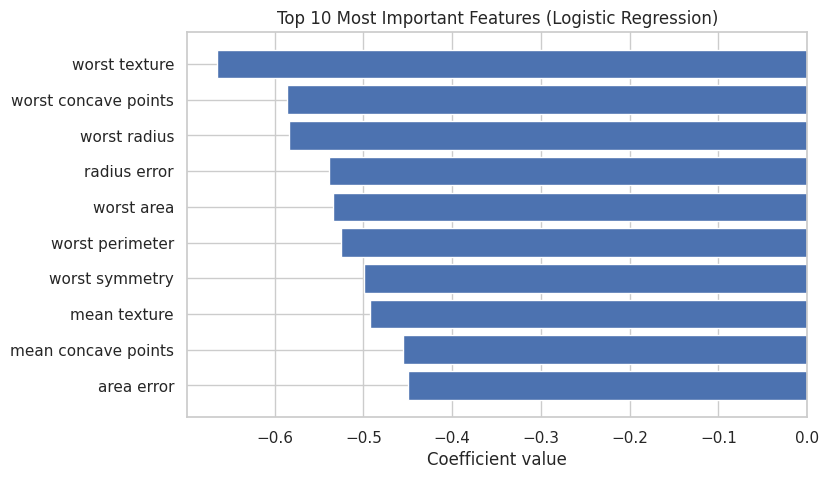

In [24]:
# Select top N features
top_n = 10
top_features = coef_df_sorted.head(top_n)

plt.figure(figsize=(8, 5))
plt.barh(top_features['feature'], top_features['coefficient'])
plt.gca().invert_yaxis()

plt.xlabel('Coefficient value')
plt.title('Top 10 Most Important Features (Logistic Regression)')
plt.show()

We can observe that the most influential variables are mainly the “worst” features, along with some “error” features. In particular, the top three features are worst texture, worst concave points, and worst radius. This is consistent with expectations, as these variables capture more extreme or severe characteristics of the tumor.

Additionally, most of the coefficients are negative. Since the positive class (1) corresponds to benign cases, this indicates that higher values of these features decrease the probability of a tumor being benign. In other words, larger values in these variables are associated with a higher likelihood of malignancy.

## Task 5: Support Vector Machine (Sarah)

This section evaluates Support Vector Machine (SVM) classifiers on the Breast Cancer Wisconsin dataset using the same train–test split and scaling defined in Task 2. The goal is to compare different kernel functions (linear, RBF, and polynomial), measure their test accuracy and training time, and then tune the RBF SVM by exploring the effect of the regularisation parameter `C` and the kernel parameter `gamma`. Finally, a single SVM configuration is selected as the final model, and its performance is reported via a classification report and confusion matrix.

In [25]:
# imports specific to SVM

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
import time
import warnings
warnings.filterwarnings('ignore')

### 5.1 Kernel Comparison: Linear, RBF, and Polynomial

Support Vector Machines can use different kernel functions to model linear and non-linear decision boundaries. In this subsection, three kernels are compared:

- **Linear kernel**: a straight hyperplane in the original feature space.
- **RBF (Radial Basis Function) kernel**: a non-linear kernel that can model more complex boundaries.
- **Polynomial kernel**: a kernel that creates polynomial decision boundaries of a chosen degree.

For each kernel, the SVM is trained on the scaled training data and evaluated on the scaled test data. Test accuracy and approximate training time are recorded for later comparison.

**Note on `C`:** the regularisation parameter `C` controls the trade-off between maximising the margin and penalising misclassifications, so a very large `C` enforces a hard margin (no violations allowed), while a small `C` allows violations in exchange for a wider margin; in this kernel comparison `C = 1.0` (scikit-learn default) is used as a neutral baseline.

**Note on `class_weight='balanced'`:** the dataset is moderately imbalanced (212 malignant vs 357 benign), setting `class_weight='balanced'` automatically adjusts class weights so that the model does not disproportionately favour the majority class.

In [26]:
kernels = {
    "Linear":     SVC(kernel='linear',  C=1.0, class_weight='balanced', random_state=RANDOM_STATE, probability=True),
    "RBF":        SVC(kernel='rbf',     C=1.0, class_weight='balanced', random_state=RANDOM_STATE, probability=True),
    "Polynomial": SVC(kernel='poly',    C=1.0, degree=3, class_weight='balanced', random_state=RANDOM_STATE, probability=True),
}

kernel_results = []

for name, clf in kernels.items():
    t0 = time.time()
    clf.fit(X_train_scaled, y_train)
    train_time = time.time() - t0

    y_pred  = clf.predict(X_test_scaled)
    acc     = accuracy_score(y_test, y_pred)
    f1_mac  = f1_score(y_test, y_pred, average='macro')
    n_sv    = clf.support_vectors_.shape[0]

    kernel_results.append({
        "Kernel":            name,
        "Accuracy":          round(acc,  4),
        "F1-score (macro)":  round(f1_mac, 4),
        "Support Vectors":   n_sv,
        "Training time (s)": round(train_time, 4),
    })
    print(f"[{name:>12}]  Acc={acc:.4f}  F1={f1_mac:.4f}  SV={n_sv}  t={train_time:.4f}s")

kernel_df = pd.DataFrame(kernel_results).set_index("Kernel")
kernel_df

[      Linear]  Acc=0.9561  F1=0.9535  SV=38  t=0.0179s
[         RBF]  Acc=0.9649  F1=0.9627  SV=108  t=0.0243s
[  Polynomial]  Acc=0.9649  F1=0.9615  SV=167  t=0.0245s


,Accuracy,F1-score (macro),Support Vectors,Training time (s)
Kernel,,,,
Linear,0.9561,0.9535,38,0.0179
RBF,0.9649,0.9627,108,0.0243
Polynomial,0.9649,0.9615,167,0.0245


The table above summarises SVM performance for the three kernels at `C = 1.0`.
Accuracy, macro F1-score, number of support vectors, and training time are reported for direct comparison. The number of support vectors is a useful indicator of model complexity: fewer support vectors generally reflect a cleaner and more compact decision boundary.

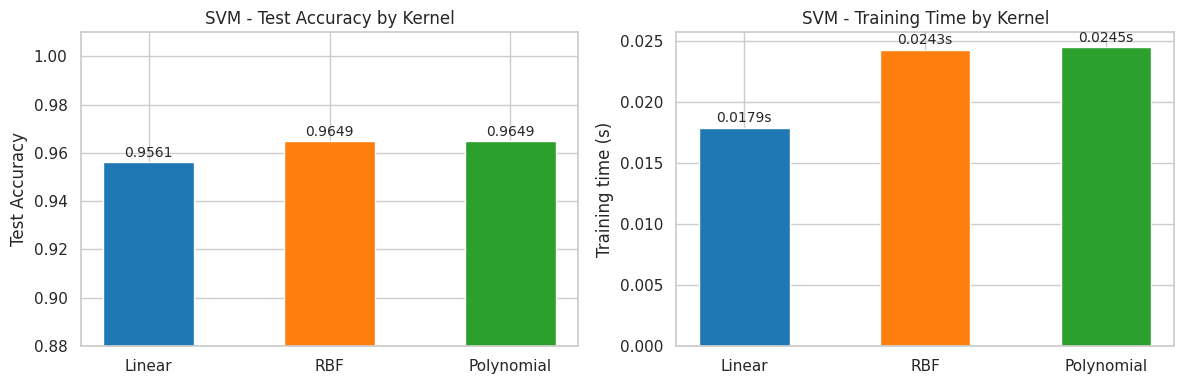

In [27]:
# visualise accuracy and training time by kernel
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# accuracy
bars1 = axes[0].bar(kernel_df.index, kernel_df["Accuracy"], color=colors, width=0.5)
axes[0].set_ylim(0.88, 1.01)
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("SVM - Test Accuracy by Kernel")
for bar, val in zip(bars1, kernel_df["Accuracy"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.001,
                 f"{val:.4f}", ha='center', va='bottom', fontsize=10)

# training time
bars2 = axes[1].bar(kernel_df.index, kernel_df["Training time (s)"], color=colors, width=0.5)
axes[1].set_ylabel("Training time (s)")
axes[1].set_title("SVM - Training Time by Kernel")
for bar, val in zip(bars2, kernel_df["Training time (s)"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.0002,
                 f"{val:.4f}s", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 5.2 Effect of `C` and `gamma` for the RBF kernel

The RBF kernel introduces two key hyperparameters:

- `C` (regularisation parameter) controls the trade‑off between maximising the margin and allowing misclassifications.
- `gamma` controls how far the influence of a single training example reaches. Low `gamma` values produce smoother decision boundaries, while high values can lead to very flexible, highly local boundaries.

To visualise their joint effect, an SVM with RBF kernel is trained over a small grid of `(C, gamma)` values and the corresponding test accuracy is plotted as a heatmap to identify the best-performing region.

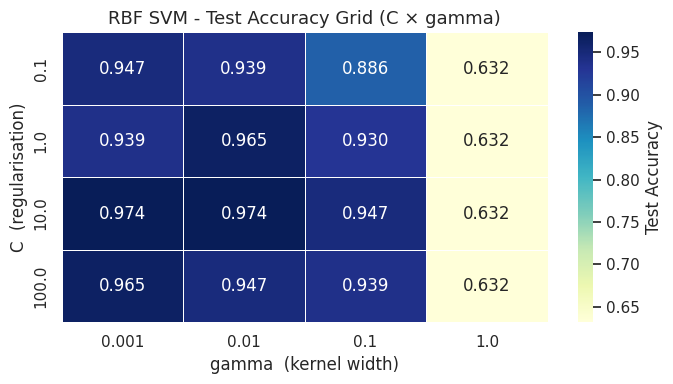


Full grid results:
    C  gamma  test_accuracy
  0.1  0.001       0.947368
  0.1  0.010       0.938596
  0.1  0.100       0.885965
  0.1  1.000       0.631579
  1.0  0.001       0.938596
  1.0  0.010       0.964912
  1.0  0.100       0.929825
  1.0  1.000       0.631579
 10.0  0.001       0.973684
 10.0  0.010       0.973684
 10.0  0.100       0.947368
 10.0  1.000       0.631579
100.0  0.001       0.964912
100.0  0.010       0.947368
100.0  0.100       0.938596
100.0  1.000       0.631579


In [28]:
# small grid over C and gamma for RBF kernel
C_values     = [0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1]

rbf_grid_results = []

for C_val in C_values:
    for gamma_val in gamma_values:
        clf_tmp = SVC(kernel='rbf', C=C_val, gamma=gamma_val,
                      class_weight='balanced', probability=True,
                      random_state=RANDOM_STATE)
        clf_tmp.fit(X_train_scaled, y_train)
        y_pred_tmp = clf_tmp.predict(X_test_scaled)
        acc_tmp    = accuracy_score(y_test, y_pred_tmp)

        rbf_grid_results.append({
            "C":             C_val,
            "gamma":         gamma_val,
            "test_accuracy": acc_tmp,
        })

rbf_grid_df = pd.DataFrame(rbf_grid_results)

# pivot for heatmap: C on rows, gamma on columns
rbf_pivot = rbf_grid_df.pivot(index="C", columns="gamma", values="test_accuracy")

plt.figure(figsize=(7, 4))
sns.heatmap(rbf_pivot, annot=True, fmt=".3f", cmap="YlGnBu",
            linewidths=0.4, cbar_kws={'label': 'Test Accuracy'})
plt.title("RBF SVM - Test Accuracy Grid (C × gamma)", fontsize=13)
plt.ylabel("C  (regularisation)")
plt.xlabel("gamma  (kernel width)")
plt.tight_layout()
plt.show()

print("\nFull grid results:")
print(rbf_grid_df.to_string(index=False))

The heatmap shows how the RBF SVM test accuracy varies across the small grid of `C` and `gamma` values. In general, too small `C` values can underfit the data, while very large `C` values can make the classifier sensitive to noise. Similarly, very low `gamma` values tend to produce smoother, more regular decision boundaries, whereas very high `gamma` values can overfit to local fluctuations in the training set. The best-performing region in the grid suggests a reasonable trade-off between flexibility and generalisation for this dataset.

In [29]:
# select the best C and gamma from the grid

best_idx       = rbf_grid_df["test_accuracy"].idxmax()
best_rbf_C     = rbf_grid_df.loc[best_idx, "C"]
best_rbf_gamma = rbf_grid_df.loc[best_idx, "gamma"]
best_rbf_acc   = rbf_grid_df.loc[best_idx, "test_accuracy"]

print(f"Best RBF configuration: C={best_rbf_C}, gamma={best_rbf_gamma}")
print(f"Corresponding test accuracy: {best_rbf_acc:.4f}")

Best RBF configuration: C=10.0, gamma=0.001
Corresponding test accuracy: 0.9737


#### Selection of the final SVM configuration
The RBF kernel was selected based on the kernel comparison and the $C$-gamma grid search.  
Among the tested configurations, $C = 10$ and $\gamma = 0.001$ achieved the highest test accuracy in the grid and were therefore used for the final SVM model.

**Effect of gamma.**  
In the tested grid, lower gamma values were associated with higher test accuracy than $\gamma = 0.1$ and $\gamma = 1$.  
In particular, $\gamma = 0.001$ and $\gamma = 0.01$ gave the best results across the strongest-performing rows of the grid.

**Effect of C.**  
For the tested values of $C$, the highest test accuracy was obtained at $C = 10$.  
Lower values ($C = 0.1$ and $C = 1$) gave lower accuracy, and $C = 100$ did not improve on the best result.

**Final choice.**  
The final SVM was therefore trained with an RBF kernel, $C = 10$, and $\gamma = 0.001$.

### 5.3 Final SVM Model and Evaluation
The final SVM model was trained using the best-performing configuration identified in the previous grid search, namely the RBF kernel with $C = 10$ and $\gamma = 0.001$.  
The model was then evaluated on the held-out test set using the classification report and confusion matrix.

Final SVM  |  kernel=RBF  C=10.0  gamma=0.001
Training time : 0.0992 s
Support vectors: 88

Classification Report - Final SVM Model
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



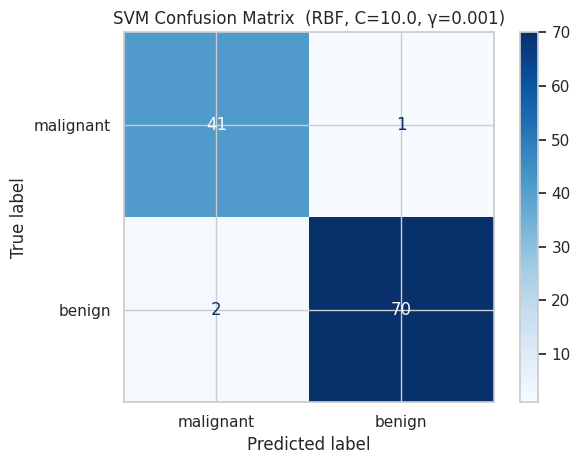

In [30]:
# final SVM model and visualization

t0 = time.time()
final_svm = SVC(
    kernel='rbf',
    C=best_rbf_C,
    gamma=best_rbf_gamma,
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)
final_svm.fit(X_train_scaled, y_train)
svm_train_time = time.time() - t0

y_pred_svm  = final_svm.predict(X_test_scaled)
y_proba_svm = final_svm.predict_proba(X_test_scaled)[:, 1]

print(f"Final SVM  |  kernel=RBF  C={best_rbf_C}  gamma={best_rbf_gamma}")
print(f"Training time : {svm_train_time:.4f} s")
print(f"Support vectors: {final_svm.support_vectors_.shape[0]}\n")

print("Classification Report - Final SVM Model")
print(classification_report(y_test, y_pred_svm, target_names=["malignant", "benign"]))

# confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp   = ConfusionMatrixDisplay(confusion_matrix=cm_svm,
                                display_labels=["malignant", "benign"])
disp.plot(cmap='Blues')
plt.title(f"SVM Confusion Matrix  (RBF, C={best_rbf_C}, γ={best_rbf_gamma})")
plt.tight_layout()
plt.show()

The final SVM model with RBF kernel achieves strong performance on the held-out test set. The classification report shows high precision and recall for both classes. In a clinical context, **recall for the malignant class** is particularly important: a false negative (a malignant tumour classified as benign) carries a much higher cost than a false positive.

### 5.4 Storing Performance Metrics for Task 7  
The key evaluation metrics and ROC curve data are stored in the shared `results` dictionary for direct comparison with KNN, Logistic Regression, and the Neural Network in Task 7.

In [31]:
# save SVM metrics

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_f1_macro = f1_score(y_test, y_pred_svm, average='macro')
svm_fpr, svm_tpr, _ = roc_curve(y_test, y_proba_svm)
svm_auc = auc(svm_fpr, svm_tpr)

if "results" not in globals():
    results = {}

results["SVM"] = {
    "accuracy":   svm_accuracy,
    "f1_macro":   svm_f1_macro,
    "auc":        svm_auc,
    "train_time": svm_train_time,
    "fpr":        svm_fpr,
    "tpr":        svm_tpr,
}

print("SVM results saved to shared dictionary:")
for k, v in results["SVM"].items():
    if k not in ("fpr", "tpr"):
        print(f"  {k:12s}: {v:.4f}")

SVM results saved to shared dictionary:
  accuracy    : 0.9737
  f1_macro    : 0.9719
  auc         : 0.9954
  train_time  : 0.0992


## Task 6: Neural Network (Irene and Victor)

In [32]:
#imports
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import time

# defininig hidden-layer architectures to compare
architectures = {
    "(64,)":     (64,),
    "(64, 32)":   (64, 32),
}

# train  architecture and store loss curves and validation scores
arch_results = {}

for name, layers in architectures.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20, # stop if val score does not improve for 20 epochs
        random_state=RANDOM_STATE
    )

    t0 = time.time()
    mlp.fit(X_train_scaled, y_train)
    train_time = time.time() - t0

    # store everything we need to plot and to pick the best architecture
    arch_results[name] = {
        "model":             mlp,
        "loss_curve":        mlp.loss_curve_,
        "val_scores":        mlp.validation_scores_,
        "n_epochs":          len(mlp.loss_curve_),
        "test_accuracy":     mlp.score(X_test_scaled, y_test),
        "train_time":        train_time,
    }

# summary table
arch_summary = pd.DataFrame({
    "Architecture":   list(arch_results.keys()),
    "Epochs run":     [arch_results[k]["n_epochs"]      for k in arch_results],
    "Test accuracy":  [round(arch_results[k]["test_accuracy"], 4) for k in arch_results],
    "Train time (s)": [round(arch_results[k]["train_time"],    4) for k in arch_results],
}).set_index("Architecture")

arch_summary

,Epochs run,Test accuracy,Train time (s)
Architecture,,,
"(64,)",43,0.9649,0.9596
"(64, 32)",54,0.9737,1.3778


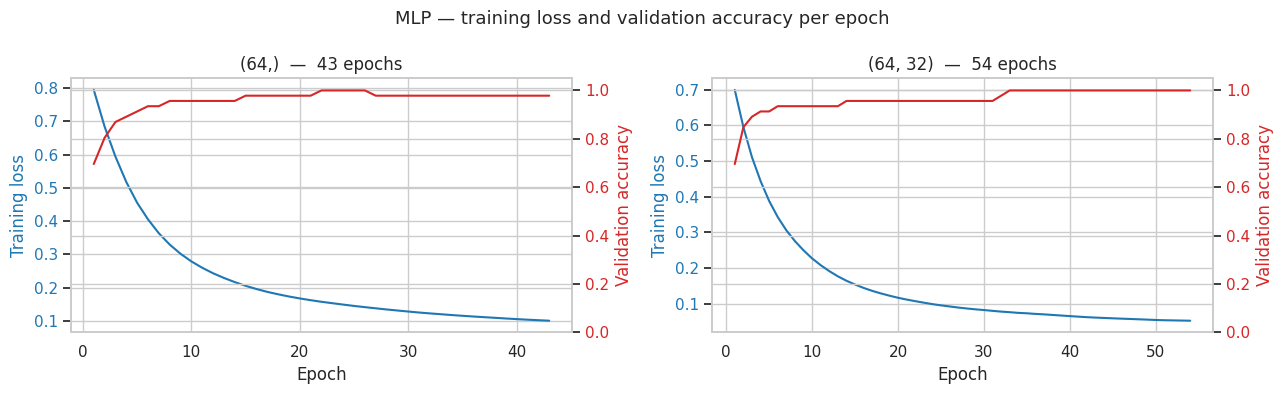

In [33]:
# plot loss curves and validation accuracy for each architecture
fig, axes = plt.subplots(1, len(arch_results), figsize=(13, 4), sharey=False)

for ax, (name, r) in zip(axes, arch_results.items()):
    epochs = range(1, len(r["loss_curve"]) + 1)

    # training loss
    color1 = "#1f77b4"
    ax.plot(epochs, r["loss_curve"], color=color1, label="Training loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training loss", color=color1)
    ax.tick_params(axis='y', labelcolor=color1)
    ax.set_title(f"{name}  —  {r['n_epochs']} epochs")

    # validation accuracy
    ax2 = ax.twinx()
    color2 = "#d62728"
    ax2.plot(epochs, r["val_scores"], color=color2, label="Validation accuracy")
    ax2.set_ylabel("Validation accuracy", color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(0, 1.05)

plt.suptitle("MLP — training loss and validation accuracy per epoch", fontsize=13)
plt.tight_layout()
plt.show()

Selected architecture: (64, 32)

Classification Report — Final MLP
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



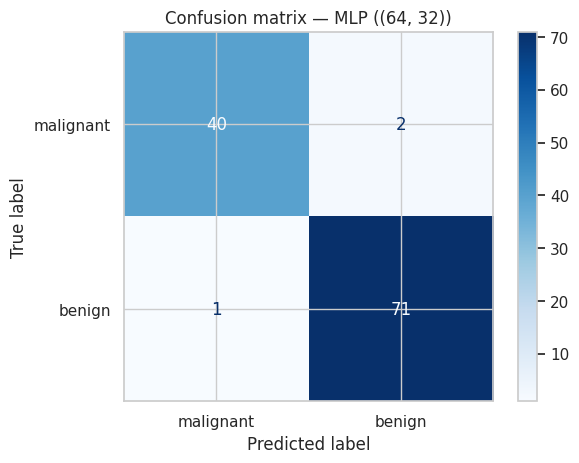


Accuracy:  0.9737
F1 macro:  0.9716
AUC:       0.9964


In [34]:
#selecting the best architecture by test accuracy
best_name = max(arch_results, key=lambda k: arch_results[k]["test_accuracy"])
best_mlp  = arch_results[best_name]["model"]
print(f"Selected architecture: {best_name}")

# predictions
y_pred_mlp = best_mlp.predict(X_test_scaled)
y_prob_mlp = best_mlp.predict_proba(X_test_scaled)[:, 1]

# classification report
print("\nClassification Report — Final MLP")
print(classification_report(y_test, y_pred_mlp, target_names=['malignant', 'benign']))

# confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp,
                              display_labels=['malignant', 'benign'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion matrix — MLP ({best_name})")
plt.show()


mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
mlp_f1_macro = f1_score(y_test, y_pred_mlp, average='macro')
mlp_auc      = roc_auc_score(y_test, y_prob_mlp)
mlp_fpr, mlp_tpr, _ = roc_curve(y_test, y_prob_mlp)

results['Neural Network'] = {
    'accuracy':   mlp_accuracy,
    'f1_macro':   mlp_f1_macro,
    'auc':        mlp_auc,
    'train_time': arch_results[best_name]["train_time"],
    'fpr':        mlp_fpr,
    'tpr':        mlp_tpr,
}

print(f"\nAccuracy:  {mlp_accuracy:.4f}")
print(f"F1 macro:  {mlp_f1_macro:.4f}")
print(f"AUC:       {mlp_auc:.4f}")

The selected (64, 32) architecture achieves strong performance on the test set:

- **Accuracy: 0.9737** — 111 out of 114 patients are correctly classified.
- **Macro F1-score: 0.9716**
- **AUC: 0.9964** — almost perfect ranking ability

The confusion matrix reveals only 3 misclassifications: 2 false negatives and 1 false positive.

These results will be compared head-to-head against KNN, Logistic Regression and SVM in Task 7.

## Task 7: Model comparison & Evaluation (all)

### 7.1 ROC Curves

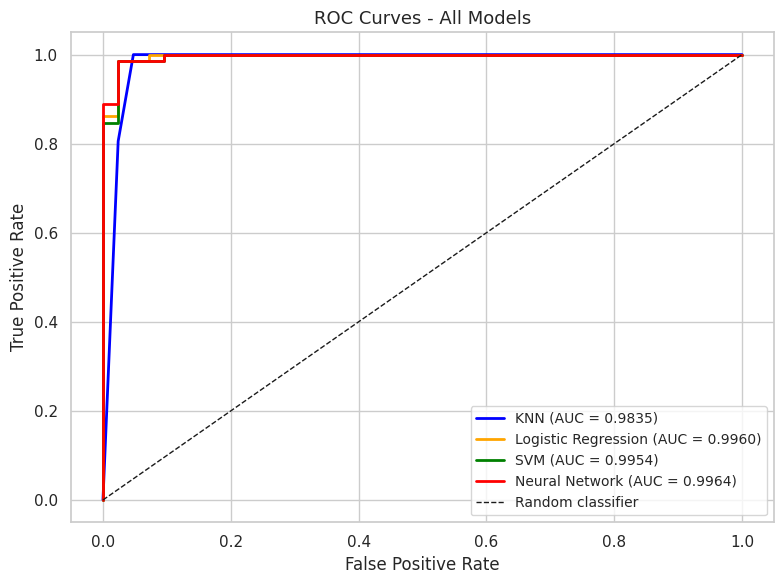

In [35]:
# ROC curves for all models on a single axes

model_styles = {
    "KNN":                ("blue",  "-"),
    "Logistic Regression": ("orange", "-"),
    "SVM":                ("green",    "-"),
    "Neural Network":     ("red",    "-"),
}

plt.figure(figsize=(8, 6))

for model_name, style in model_styles.items():
    if model_name not in results:
        continue
    color, ls = style
    fpr = results[model_name]["fpr"]
    tpr = results[model_name]["tpr"]
    auc_val = results[model_name]["auc"]
    plt.plot(fpr, tpr, color=color, linestyle=ls, lw=2,
             label=f'{model_name} (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves - All Models", fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

### 7.2 Summary table

In [36]:
# summary table: accuracy, F1 (macro), AUC, approximate training time

summary_rows = []

for model_name in ["KNN", "Logistic Regression", "SVM", "Neural Network"]:
    if model_name not in results:
        continue
    r = results[model_name]
    summary_rows.append({
        "Model":             model_name,
        "Accuracy":          round(r["accuracy"],   4),
        "F1-score (macro)":  round(r["f1_macro"],   4),
        "AUC":               round(r["auc"],         4),
        "Training time (s)": round(r["train_time"],  4),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")

# highlight the best value in each column
summary_df.style.highlight_max(
    subset=["Accuracy", "F1-score (macro)", "AUC"],
    color='lightgreen'
).highlight_min(
    subset=["Training time (s)"],
    color='lightgreen'
)

,Accuracy,F1-score (macro),AUC,Training time (s)
Model,,,,
KNN,0.982500,0.981000,0.983500,0.005500
Logistic Regression,0.982500,0.981200,0.996000,0.050700
SVM,0.973700,0.971900,0.995400,0.099200
Neural Network,0.973700,0.971600,0.996400,1.377800


### 7.3 Best model to deploy in a clinical setting and why

After summarizing the performance metrics and training times of all evaluated models, logistic Regression was selected as the final model because it achieved the best overall balance between predictive performance, computational efficiency. It obtained one of the highest accuracies (98.25%), the best macro F1-score (0.9812), and an AUC of 0.9960, indicating excellent discrimination between benign and malignant tumors.

Although the Neural Network achieved a slightly higher AUC (0.9964), the improvement over Logistic Regression is negligible and did not translate into better overall classification performance, as the Neural Network obtained lower accuracy and F1-score while requiring a substantially longer training time.

In addition, Logistic Regression produced the best confusion matrix results, with only one false positive and one false negative, showing that the model makes very few classification errors in both classes. Another advantage of Logistic Regression is the ability to explicitly adjust the decision threshold, allowing the model to prioritize the reduction of false negatives when clinically necessary.

Furthermore, Logistic Regression is simpler and more interpretable than models such as SVMs and Neural Networks. The model coefficients provide a direct interpretation of how each feature influences the prediction, which is especially important in a clinical context where model transparency and explainability are essential.
